In [1]:
# Cell 1 — imports
import pandas as pd
import numpy as np
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import plotly.express as px
import matplotlib.pyplot as plt

print("Imports done!")

c:\Users\ramki\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports done!


In [2]:
# Cell 2 — load data
df = pd.read_csv("E:/Research Paper topic/data/processed_papers.csv")
embeddings = np.load("E:/Research Paper topic/data/embeddings.npy")
texts = df['clean_text'].tolist()

print("Papers loaded:", len(texts))
print("Embeddings shape:", embeddings.shape)

Papers loaded: 300
Embeddings shape: (300, 384)


In [3]:
# Cell 3 — run BERTopic (takes 2-3 minutes)
print("Running BERTopic clustering...")

vectorizer = CountVectorizer(ngram_range=(1, 2), stop_words="english")

topic_model = BERTopic(
    vectorizer_model=vectorizer,
    nr_topics="auto",
    verbose=True
)

topics, probs = topic_model.fit_transform(texts, embeddings)

df['topic'] = topics
df.to_csv("E:/Research Paper topic/data/processed_papers.csv", index=False)
print("Clustering done!")
print("Total topics found:", len(set(topics)) - 1)  # -1 for noise topic

2026-05-31 00:06:41,343 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Running BERTopic clustering...


2026-05-31 00:06:54,464 - BERTopic - Dimensionality - Completed ✓
2026-05-31 00:06:54,467 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-31 00:06:54,498 - BERTopic - Cluster - Completed ✓
2026-05-31 00:06:54,499 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-31 00:06:54,685 - BERTopic - Representation - Completed ✓
2026-05-31 00:06:54,686 - BERTopic - Topic reduction - Reducing number of topics
2026-05-31 00:06:54,696 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-31 00:06:54,860 - BERTopic - Representation - Completed ✓
2026-05-31 00:06:54,861 - BERTopic - Topic reduction - Reduced number of topics from 9 to 9


Clustering done!
Total topics found: 8


In [4]:
# Cell 4 — view topic keywords
topic_info = topic_model.get_topic_info()
topic_info.to_csv("E:/Research Paper topic/data/topic_info.csv", index=False)
print("Number of topics:", len(topic_info) - 1)
topic_info.head(20)

Number of topics: 8


,Topic,Count,Name,Representation,Representative_Docs
0,-1,80,-1_learning_policy_reinforcement_model,"[learning, policy, reinforcement, model, reinf...",[navol navigation policy online imitation lear...
1,0,37,0_policy_learning_task_reinforcement learning,"[policy, learning, task, reinforcement learnin...",[rankq offlinetoonline reinforcement learning ...
2,1,36,1_model_task_reasoning_manipulation,"[model, task, reasoning, manipulation, learnin...",[expoft sampleefficient reinforcement learning...
3,2,34,2_driving_learning_autonomous_safety,"[driving, learning, autonomous, safety, scenar...",[reap reinforcementlearning endtoend autonomou...
4,3,33,3_locomotion_motion_robot_learning,"[locomotion, motion, robot, learning, humanoid...",[parkourformer integrating predictive supervis...
5,4,29,4_control_learning_flight_policy,"[control, learning, flight, policy, quadrotor,...",[aerial inspection behavior via rlbased quadro...
6,5,23,5_communication_learning_robot_task,"[communication, learning, robot, task, multiro...",[scalecomm shared contrastivelyaligned latent ...
7,6,14,6_tactile_object_manipulation_learning,"[tactile, object, manipulation, learning, poli...",[learning tactileaware quadrupedal locomanipul...
8,7,14,7_control_policy_gradient_optimization,"[control, policy, gradient, optimization, lear...",[learning hybridcontrol policy highprecision i...


In [5]:
# Cell 5 — visualize clusters
fig = px.scatter(
    df[df['topic'] >= 0],
    x='umap_x', y='umap_y',
    color=df[df['topic'] >= 0]['topic'].astype(str),
    hover_data=['title', 'year'],
    title="Research paper topic clusters (Reinforcement Learning Robotics)",
    opacity=0.7,
    width=900, height=600
)
fig.show()

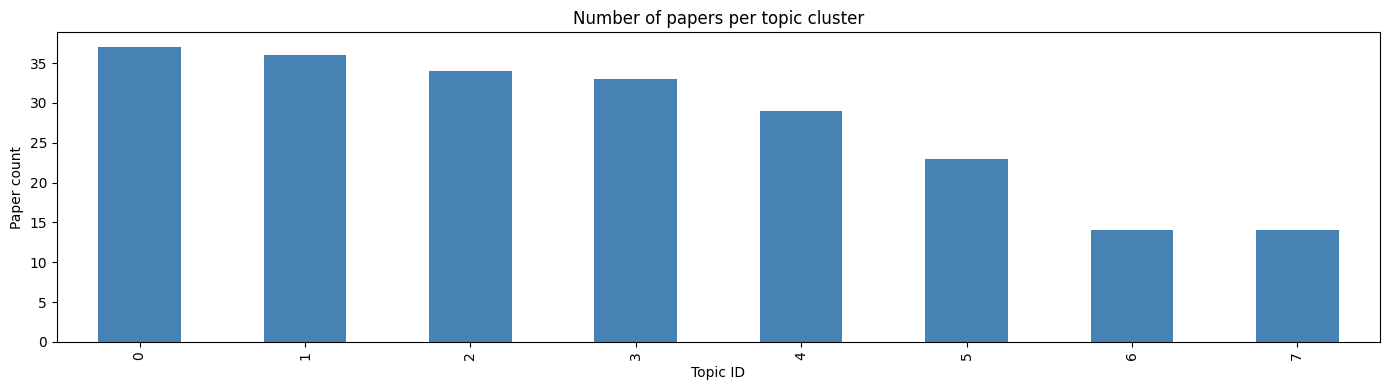

In [6]:
# Cell 6 — cluster sizes bar chart
topic_counts = df[df['topic'] >= 0]['topic'].value_counts().sort_index()

plt.figure(figsize=(14, 4))
topic_counts.plot(kind='bar', color='steelblue')
plt.title("Number of papers per topic cluster")
plt.xlabel("Topic ID")
plt.ylabel("Paper count")
plt.tight_layout()
plt.show()

In [7]:
# Cell 7 — print top keywords for each topic
print("Top keywords per topic:\n")
for topic_id in sorted(topic_info['Topic'].tolist()):
    if topic_id == -1:
        continue
    keywords = topic_model.get_topic(topic_id)
    words = [w[0] for w in keywords[:8]]
    print(f"Topic {topic_id}: {', '.join(words)}")

Top keywords per topic:

Topic 0: policy, learning, task, reinforcement learning, action, reinforcement, offline, critic
Topic 1: model, task, reasoning, manipulation, learning, action, vla, visual
Topic 2: driving, learning, autonomous, safety, scenario, traffic, reinforcement, vehicle
Topic 3: locomotion, motion, robot, learning, humanoid, policy, reinforcement, reinforcement learning
Topic 4: control, learning, flight, policy, quadrotor, obstacle, environment, uav
Topic 5: communication, learning, robot, task, multirobot, multiagent, agent, reinforcement
Topic 6: tactile, object, manipulation, learning, policy, sensing, contact, dexterous
Topic 7: control, policy, gradient, optimization, learning, parameter, shape, objective


In [8]:
# Cell 8 — BERTopic interactive visualization
topic_model.visualize_topics()